## Class Activity 1 — Comparing Representation Methods

Represent the words **Cat**, **Dog**, and **Animal** using One-Hot Encoding and Word Embeddings, then discuss the differences.

### 1. One-Hot Encoding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

In [6]:
# Vocabulary for the three words
vocabulary = [['cat'], ['dog'], ['animal']]
encoder = OneHotEncoder(sparse_output=False)
one_hot_matrix = encoder.fit_transform(vocabulary)

words = [row[0] for row in vocabulary]
one_hot = dict(zip(words, one_hot_matrix))

print('One-Hot Encoding')
print('Categories:', encoder.categories_)
print()
for word, vec in one_hot.items():
    print(f'  {word:<8}: {vec}')

print(f'Vector size per word : {one_hot_matrix.shape[1]} (equals vocabulary size)')
print(f'Non-zero values      : 1 per vector (always)')

# Similarity between one-hot vectors
print('Cosine similarities (One-Hot):')
pairs = [('cat', 'dog'), ('cat', 'animal'), ('dog', 'animal')]
for w1, w2 in pairs:
    sim = cosine_similarity([one_hot[w1]], [one_hot[w2]])[0][0]
    print(f'  {w1} vs {w2:<8}: {sim:.4f}')

One-Hot Encoding
Categories: [array(['animal', 'cat', 'dog'], dtype=object)]

  cat     : [0. 1. 0.]
  dog     : [0. 0. 1.]
  animal  : [1. 0. 0.]
Vector size per word : 3 (equals vocabulary size)
Non-zero values      : 1 per vector (always)
Cosine similarities (One-Hot):
  cat vs dog     : 0.0000
  cat vs animal  : 0.0000
  dog vs animal  : 0.0000


### 2. Word Embeddings (Word2Vec)

In [7]:
# Corpus that places cat, dog, and animal in shared contexts
corpus = [
    'a cat is a domestic animal kept as a pet',
    'a dog is a loyal domestic animal and a great pet',
    'cats and dogs are common household animals',
    'an animal is a living organism that can move and breathe',
    'the cat sat quietly on the mat',
    'the dog barked loudly at the stranger',
    'both the cat and the dog are friendly animals',
    'veterinarians treat sick animals including cats and dogs',
    'a lion is a wild animal while a cat is a tame one',
    'dogs and cats are the most popular pets in the world',
    'every animal needs food water and shelter to survive',
    'my pet cat and my pet dog get along very well'
]

tokenized = [simple_preprocess(s) for s in corpus]

w2v = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=4,
    min_count=1,
    sg=1,
    epochs=300,
    seed=42
)

print('Word Embeddings (Word2Vec)\n')
for word in words:
    vec = w2v.wv[word]
    print(f'  {word:<8}: {np.round(vec[:6], 4)} ... ({len(vec)} dims total)')

print('\nCosine similarities (Word2Vec):')
for w1, w2 in pairs:
    sim = w2v.wv.similarity(w1, w2)
    print(f'  {w1} vs {w2:<8}: {sim:.4f}')

Word Embeddings (Word2Vec)

  cat     : [ 0.1149 -0.0884  0.071   0.0032  0.0564  0.0487] ... (50 dims total)
  dog     : [ 0.1102 -0.1071  0.0582 -0.011   0.0762  0.0461] ... (50 dims total)
  animal  : [ 0.161  -0.1346  0.1119 -0.032   0.0661  0.0856] ... (50 dims total)

Cosine similarities (Word2Vec):
  cat vs dog     : 0.9931
  cat vs animal  : 0.9933
  dog vs animal  : 0.9900


---
## Class Activity 2 — Similarity Investigation

Using the trained Word2Vec model, identify similar words, opposite words, and related words.

In [8]:
print('Similar Words (most_similar)\n')
for word in words:
    similar = w2v.wv.most_similar(word, topn=3)
    print(f"  '{word}':")
    for sw, score in similar:
        print(f'    {sw:<12} {score:.4f}')
    print()

Similar Words (most_similar)

  'cat':
    pet          0.9949
    very         0.9941
    animal       0.9933

  'dog':
    at           0.9944
    very         0.9940
    pet          0.9939

  'animal':
    is           0.9967
    domestic     0.9956
    tame         0.9953



In [9]:
# Opposite (least similar) words are those with the lowest cosine similarity score
print('Least Similar (opposite-leaning) Words\n')
for word in words:
    least_similar = w2v.wv.most_similar(negative=[word], topn=3)
    print(f"  Least similar to '{word}':")
    for sw, score in least_similar:
        print(f'    {sw:<12} {score:.4f}')
    print()

Least Similar (opposite-leaning) Words

  Least similar to 'cat':
    common       -0.9839
    the          -0.9847
    food         -0.9853

  Least similar to 'dog':
    wild         -0.9872
    food         -0.9875
    common       -0.9878

  Least similar to 'animal':
    the          -0.9807
    popular      -0.9842
    in           -0.9846



In [10]:
# Related words — words that are similar to more than one of our target words
print('Related Words (similar to both cat AND dog)\n')
related = w2v.wv.most_similar(positive=['cat', 'dog'], topn=5)
for word, score in related:
    print(f'  {word:<12} {score:.4f}')

print('\nRelated Words (similar to dog AND animal)\n')
related2 = w2v.wv.most_similar(positive=['dog', 'animal'], topn=5)
for word, score in related2:
    print(f'  {word:<12} {score:.4f}')

Related Words (similar to both cat AND dog)

  pet          0.9962
  very         0.9958
  and          0.9947
  along        0.9945
  well         0.9941

Related Words (similar to dog AND animal)

  and          0.9969
  domestic     0.9958
  cat          0.9957
  breathe      0.9952
  is           0.9950


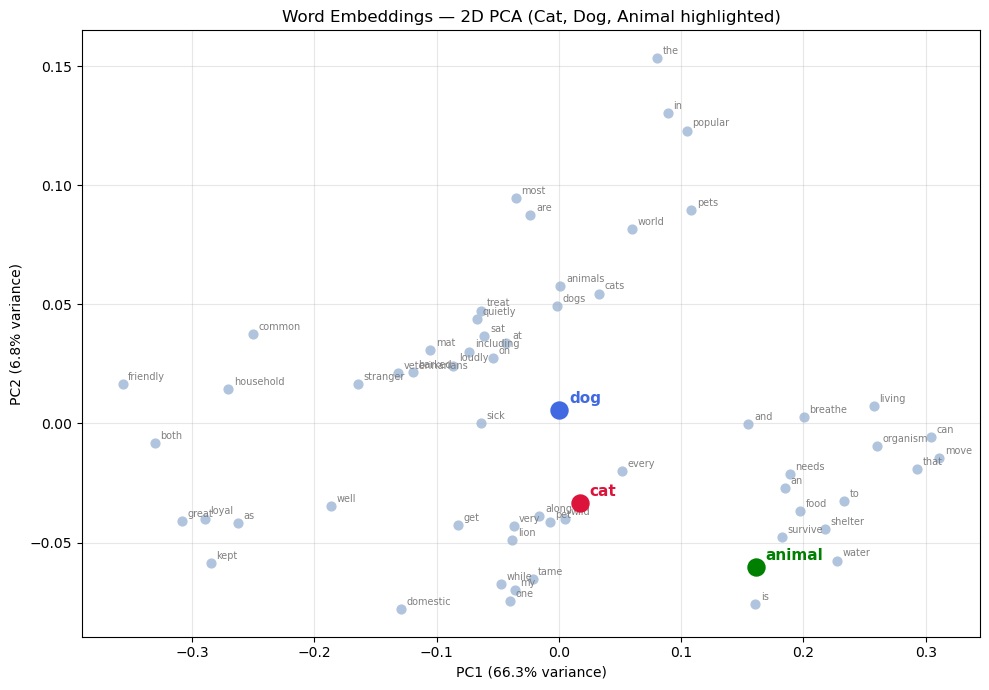

In [11]:
# Visualise all vocab words in 2D
all_words = list(w2v.wv.key_to_index.keys())
all_vectors = np.array([w2v.wv[w] for w in all_words])

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(all_vectors)

plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1], s=40, color='lightsteelblue')

# Highlight the three target words
highlight = {'cat': 'crimson', 'dog': 'royalblue', 'animal': 'green'}
for word, colour in highlight.items():
    idx = all_words.index(word)
    plt.scatter(reduced[idx, 0], reduced[idx, 1], s=150, color=colour, zorder=5)
    plt.annotate(word, (reduced[idx, 0], reduced[idx, 1]),
                 textcoords='offset points', xytext=(7, 5), fontsize=11,
                 fontweight='bold', color=colour)

for i, word in enumerate(all_words):
    if word not in highlight:
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                     textcoords='offset points', xytext=(4, 3), fontsize=7, color='grey')

plt.title('Word Embeddings — 2D PCA (Cat, Dog, Animal highlighted)', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()